In [51]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR10
import torchvision

In [52]:
batch_size=64

In [53]:
def collate_fn(batch):
    images, labels = zip(*batch)

    images = torch.tensor(
        np.stack([np.array(img) for img in images]),
        dtype=torch.float32
    )

    labels = torch.tensor(labels)

    return images, labels

In [54]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

classes = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [55]:
type(trainloader), trainloader.__iter__().__next__()[0].shape

(torch.utils.data.dataloader.DataLoader, torch.Size([64, 32, 32, 3]))

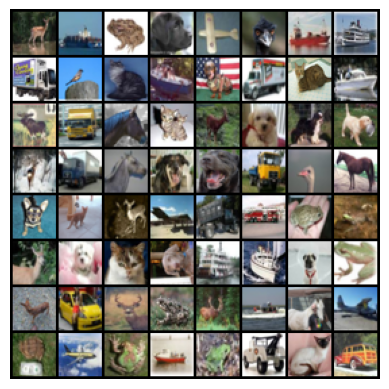

deer  ship  frog  dog   plane bird  ship  ship  truck bird  cat   ship  dog   truck cat   ship  deer  truck horse cat   deer  dog   dog   dog   deer  truck horse dog   dog   truck bird  horse dog   cat   deer  plane truck truck frog  frog  deer  dog   cat   dog   ship  ship  dog   frog  deer  car   deer  frog  deer  ship  horse plane frog  plane frog  ship  frog  truck cat   car  


In [56]:
def imshow(img):
    npimg = img.cpu().numpy().astype(np.uint8)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
images = images.permute(0, 3, 1, 2)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [57]:
import torch.nn as nn
import torch.nn.functional as F

In [58]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.c2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*5*5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.c1(x)))
        x = self.pool(F.relu(self.c2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [59]:
net = Network()

In [60]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [62]:
net = net.to(device)

In [63]:
for epoch in range(100):
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs = inputs.permute(0, 3, 1, 2) # currently shape is (64, 32, 32)
        optimizer.zero_grad()

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

In [64]:
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)

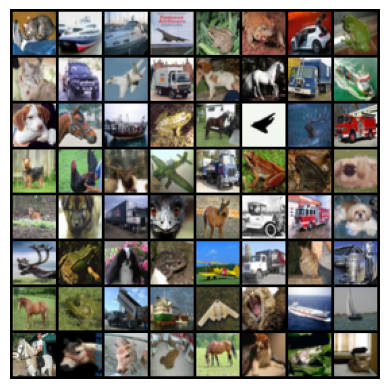

GroundTruth:  cat   ship  ship  plane


In [65]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images = images.permute(0, 3, 1, 2)
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [66]:
net = Network()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [67]:
for name, param in net.named_parameters():
    if "weight" in name:
        print(f"Layer: {name}, shape: {param.shape}")

Layer: c1.weight, shape: torch.Size([6, 3, 5, 5])
Layer: c2.weight, shape: torch.Size([16, 6, 5, 5])
Layer: fc1.weight, shape: torch.Size([128, 400])
Layer: fc2.weight, shape: torch.Size([64, 128])
Layer: fc3.weight, shape: torch.Size([10, 64])


In [68]:
outputs = net(images)

In [69]:
_, predicted = torch.max(outputs, 1)

print("Real:      ", ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
print("Predicted: ", ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Real:       cat   ship  ship  plane
Predicted:  dog   plane truck plane


In [70]:
net = net.to(device)

In [71]:
correct, total = 0, 0
net.eval()

with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.permute(0, 3, 1, 2)
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 48 %


In [72]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.permute(0, 3, 1, 2)
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 54.3 %
Accuracy for class: car   is 71.8 %
Accuracy for class: bird  is 47.5 %
Accuracy for class: cat   is 25.0 %
Accuracy for class: deer  is 39.8 %
Accuracy for class: dog   is 36.1 %
Accuracy for class: frog  is 61.9 %
Accuracy for class: horse is 47.8 %
Accuracy for class: ship  is 59.7 %
Accuracy for class: truck is 37.7 %
